In [4]:
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [5]:
MyData = pd.read_csv(r"C:\Users\user\OneDrive\Desktop\Laptop company price list\Data\laptop_price.csv", encoding= "latin1")
MyData.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [6]:
MyData.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   str    
 2   Product           1303 non-null   str    
 3   TypeName          1303 non-null   str    
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   str    
 6   Cpu               1303 non-null   str    
 7   Ram               1303 non-null   str    
 8   Memory            1303 non-null   str    
 9   Gpu               1303 non-null   str    
 10  OpSys             1303 non-null   str    
 11  Weight            1303 non-null   str    
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), str(10)
memory usage: 132.5 KB


In [7]:
MyData.describe()

,laptop_ID,Inches,Price_euros
count,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,1123.686992
std,381.172104,1.426304,699.009043
min,1.000000,10.100000,174.000000
25%,331.500000,14.000000,599.000000
50%,659.000000,15.600000,977.000000
75%,990.500000,15.600000,1487.880000
max,1320.000000,18.400000,6099.000000


In [8]:
MyData.isnull().sum()

laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64

In [9]:
MyData.shape

(1303, 13)

In [10]:
MyData["Price_euros"].agg(["max","min","mean"])

max     6099.000000
min      174.000000
mean    1123.686992
Name: Price_euros, dtype: float64

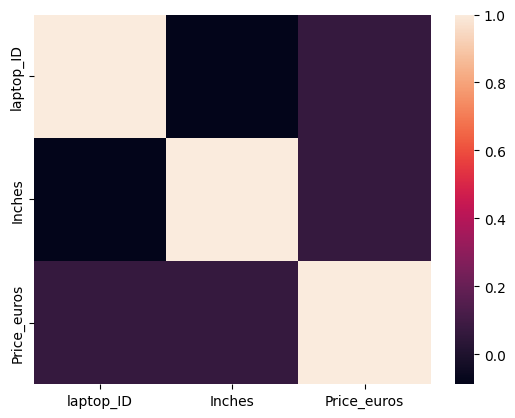

In [11]:
numeric_data = MyData.select_dtypes(include = 'number')
sns.heatmap(numeric_data.corr())
plt.show()

<Axes: >

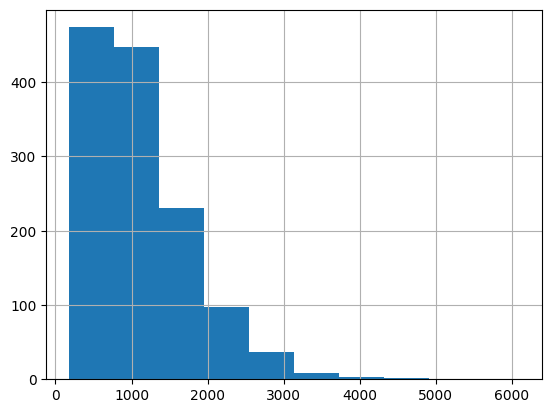

In [12]:
MyData['Price_euros'] .hist()

<Axes: >

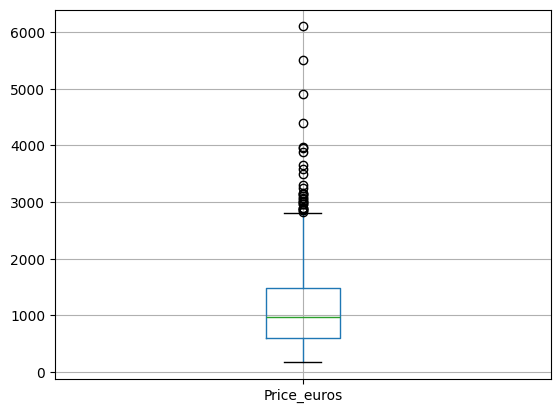

In [13]:
MyData.boxplot(column='Price_euros')

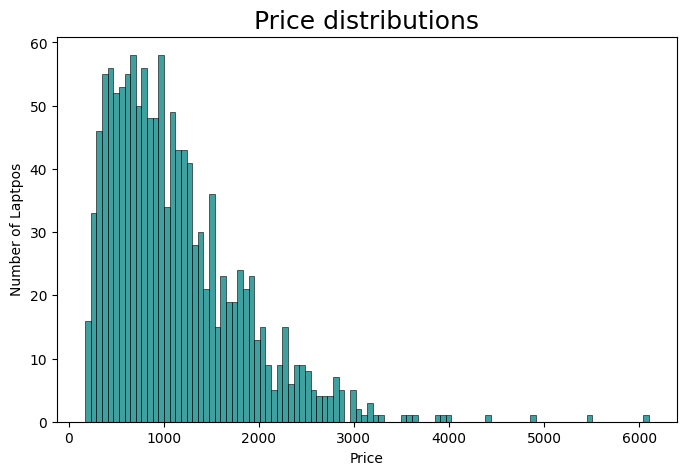

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(MyData['Price_euros'], bins=100, color='teal')
plt.title("Price distributions", fontsize=18)
plt.xlabel("Price")
plt.ylabel("Number of Laptpos")
plt.show()

In [15]:
MyData["TypeName"].value_counts()

TypeName
Notebook              727
Gaming                205
Ultrabook             196
2 in 1 Convertible    121
Workstation            29
Netbook                25
Name: count, dtype: int64

In [16]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score


In [17]:
MyData_encoded = MyData.copy()
le = LabelEncoder()
categorical_features = ['TypeName']
for col in categorical_features :
    MyData_encoded[col] = le.fit_transform(MyData_encoded[col])

MyData_encoded.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,4,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,4,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,3,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,4,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,4,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [18]:
MyData_scaled = MyData_encoded.copy()

In [19]:
MyData_scaled.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,4,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,4,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,3,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,4,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,4,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [20]:
MyData_scaled['Weight'] = MyData['Weight'].astype(str).str.replace('kg' , '' ,regex= False).str.strip().astype(float)
MyData_scaled['Ram'] = MyData['Ram'].astype(str).str.replace('GB' , '' , regex= False ).str.strip().astype(float)

In [21]:
MyData_scaled.rename(columns={
    'Weight': 'Weight_kg',
    'Ram': 'Ram_GB'
}, inplace=True)

In [22]:
MyData_scaled.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram_GB,Memory,Gpu,OpSys,Weight_kg,Price_euros
0,1,Apple,MacBook Pro,4,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8.0,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69
1,2,Apple,Macbook Air,4,13.3,1440x900,Intel Core i5 1.8GHz,8.0,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94
2,3,HP,250 G6,3,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8.0,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.00
3,4,Apple,MacBook Pro,4,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16.0,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45
4,5,Apple,MacBook Pro,4,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8.0,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.60


In [23]:
numerical_features = ['Inches' , 'Ram_GB' , 'Weight_kg']
scaler = StandardScaler()
MyData_scaled[numerical_features] = scaler.fit_transform(MyData_scaled[numerical_features])
MyData_scaled.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram_GB,Memory,Gpu,OpSys,Weight_kg,Price_euros
0,1,Apple,MacBook Pro,4,-1.204407,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,-0.075195,128GB SSD,Intel Iris Plus Graphics 640,macOS,-1.005283,1339.69
1,2,Apple,Macbook Air,4,-1.204407,1440x900,Intel Core i5 1.8GHz,-0.075195,128GB Flash Storage,Intel HD Graphics 6000,macOS,-1.050381,898.94
2,3,HP,250 G6,3,0.408772,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,-0.075195,256GB SSD,Intel HD Graphics 620,No OS,-0.268684,575.00
3,4,Apple,MacBook Pro,4,0.268495,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,1.498767,512GB SSD,AMD Radeon Pro 455,macOS,-0.313782,2537.45
4,5,Apple,MacBook Pro,4,-1.204407,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,-0.075195,256GB SSD,Intel Iris Plus Graphics 650,macOS,-1.005283,1803.60


In [24]:
numerical_features = ['Inches' , 'Ram_GB' , 'Weight_kg']
scaler = MinMaxScaler()
MyData_scaled[numerical_features] = scaler.fit_transform(MyData_scaled[numerical_features])
MyData_scaled.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram_GB,Memory,Gpu,OpSys,Weight_kg,Price_euros
0,1,Apple,MacBook Pro,4,0.385542,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,0.096774,128GB SSD,Intel Iris Plus Graphics 640,macOS,0.169576,1339.69
1,2,Apple,Macbook Air,4,0.385542,1440x900,Intel Core i5 1.8GHz,0.096774,128GB Flash Storage,Intel HD Graphics 6000,macOS,0.162095,898.94
2,3,HP,250 G6,3,0.662651,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,0.096774,256GB SSD,Intel HD Graphics 620,No OS,0.291771,575.00
3,4,Apple,MacBook Pro,4,0.638554,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,0.225806,512GB SSD,AMD Radeon Pro 455,macOS,0.284289,2537.45
4,5,Apple,MacBook Pro,4,0.385542,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,0.096774,256GB SSD,Intel Iris Plus Graphics 650,macOS,0.169576,1803.60


In [25]:
MyData = pd.get_dummies(MyData)


y = MyData['Price_euros']          
X = MyData.drop('Price_euros', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
print("train shape :",X_train.shape)
print("train shape :",X_test.shape)

train shape : (1042, 1149)
train shape : (261, 1149)


In [27]:
y_pred = lr_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.6182333284714927
MSE: 193909.418741437


In [28]:
coefficient = pd.DataFrame({
    'features: ': X.columns ,
    'coefficient': lr_model.coef_
}).sort_values(by='coefficient',ascending = False)
coefficient

,features:,coefficient
131,Product_EliteBook 820,2641.662117
137,Product_Elitebook 820,2350.588088
135,Product_EliteBook x360,2052.972841
984,Weight_1.13kg,1785.960045
393,Product_Probook 640,1670.413669
...,...,...
279,Product_Inspiron 7577,-1278.436368
76,Product_Alienware 15,-1340.060620
303,Product_Latitude 5590,-1428.105106
263,Product_Inspiron 5370,-1723.159532
